# Generowanie danych stenosis jako obrócone fragmenty naczynia — wersja ALL/DEBUG

Ten notebook tworzy dataset do modułu 5 tak, jak opisałeś:

`obraz → segmentacja → maska → skeleton → junction decision cleanup → graf → fragmenty po ~10 px → obrócone prostokąty → label 0/1 z polygon segmentation ARCADE`

Najważniejsza poprawka względem poprzedniej wersji:

- funkcja podglądu domyślnie pokazuje **wszystkie** obrócone fragmenty dla danego `image_id`, a nie tylko okolice pozytywów,
- zapisuje debugowe maski/skeletony dla przetwarzanych obrazów,
- dodaje osobny panel diagnostyczny: oryginał + anotacje, maska, skeleton, wszystkie segmenty.

Kolory na wizualizacji:

- pomarańczowy = `label=0`, fragment bez stenozy,
- czerwony = `label=1`, fragment nachodzi na polygon segmentation stenozy,
- czarny prostokąt = oryginalny axis-aligned `bbox` z COCO/ARCADE, tylko referencyjnie,
- cyjan = polygon `segmentation` stenozy z `train.json`.


## 0. Importy podstawowe

In [27]:
from __future__ import annotations

from pathlib import Path
import sys
import json
import math
import ast
import traceback
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from tqdm.auto import tqdm

from xgboost import XGBClassifier

## 1. Konfiguracja ścieżek

In [28]:
# Automatycznie znajdź root repozytorium.
cwd = Path.cwd().resolve()
REPO_ROOT = None
for c in [cwd, *cwd.parents]:
    if (c / "coronary-analysis").exists() and (c / "models").exists() and (c / "notebooks").exists():
        REPO_ROOT = c
        break

if REPO_ROOT is None:
    # Ustaw ręcznie, jeżeli automatyczne wyszukiwanie nie zadziała.
    REPO_ROOT = Path("/home/piotrrusak/Agh/coronary-stenosis-detection")

SRC_DIR = REPO_ROOT / "coronary-analysis" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ANNOTATION_JSON = (
    REPO_ROOT / "notebooks" / "raw_datasets" / "arcade" / "arcade" /
    "stenosis" / "train" / "annotations" / "train.json"
)

IMAGE_DIR = (
    REPO_ROOT / "notebooks" / "raw_datasets" / "arcade" / "arcade" /
    "stenosis" / "train" / "images"
)

MODEL_PATH = REPO_ROOT / "models" / "best_segmentation_model.pth"

OUTPUT_DIR = REPO_ROOT / "notebooks" / "processed" / "stenosis_oriented_segments"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:      ", REPO_ROOT)
print("SRC_DIR:        ", SRC_DIR)
print("ANNOTATION_JSON:", ANNOTATION_JSON)
print("IMAGE_DIR:      ", IMAGE_DIR)
print("MODEL_PATH:     ", MODEL_PATH)
print("OUTPUT_DIR:     ", OUTPUT_DIR)

assert ANNOTATION_JSON.exists(), f"Nie znaleziono train.json: {ANNOTATION_JSON}"
assert IMAGE_DIR.exists(), f"Nie znaleziono katalogu obrazów: {IMAGE_DIR}"
assert MODEL_PATH.exists(), f"Nie znaleziono wag modelu: {MODEL_PATH}"

print("\nOK — ścieżki istnieją.")


REPO_ROOT:       /home/piotrrusak/Agh/coronary-stenosis-detection
SRC_DIR:         /home/piotrrusak/Agh/coronary-stenosis-detection/coronary-analysis/src
ANNOTATION_JSON: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/raw_datasets/arcade/arcade/stenosis/train/annotations/train.json
IMAGE_DIR:       /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/raw_datasets/arcade/arcade/stenosis/train/images
MODEL_PATH:      /home/piotrrusak/Agh/coronary-stenosis-detection/models/best_segmentation_model.pth
OUTPUT_DIR:      /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments

OK — ścieżki istnieją.


## 2. Importy z biblioteki projektu

Ta komórka korzysta z funkcji repozytorium do segmentacji, skeletonizacji, budowy grafu i junction decision cleanupu.

In [29]:
import torch

from coronary_analysis.inference import load_image, load_segmentation_model, predict_mask
from coronary_analysis.topology import (
    build_vessel_graph,
    clean_mask,
    compute_distance_map,
    estimate_branch_diameters,
    prune_skeleton,
    skeletonize_mask,
)
from coronary_analysis.topology.junction_decision import (
    DEFAULT_JUNCTION_DECISION_CONFIG,
    run_junction_decision,
)
from coronary_analysis.topology.junction_decision.graph_cleanup import (
    remove_false_junctions_from_skeleton,
)
from coronary_analysis.utils import get_device

print("Importy z coronary_analysis OK")
DEFAULT_JUNCTION_DECISION_CONFIG


Importy z coronary_analysis OK


JunctionDecisionConfig(junction_group_dilation=3, min_junction_area=1, remove_radius=2, max_arm_steps=60, min_arm_len=4, enable_local_refine=True, local_crop_size=80, local_remove_radius=2, local_max_arm_steps=80, local_min_arm_len=2, local_keep_short_arms=True, local_prune_min_branch_length=2, fake_mean_cost_threshold=0.25, fake_max_cost_threshold=0.4, allow_two_arm_fake=True, min_area_for_two_arm_fake=6, enable_thickness_fake=True, thickness_radius=5, thickness_fake_threshold=2.0, thickness_fake_max_extra=1.0, thickness_area_threshold=4, soft_false_mean_cost_extra=0.15, graph_cleanup_neighbor_score_threshold=0.3, max_pairing_arms=8, graph_cleanup_max_center_distance=8.0)

## 3. Parametry pipeline'u

In [ ]:
ENCODER_NAME = "resnet34"
IMG_SIZE = 256
SEGMENTATION_THRESHOLD = 0.5

MASK_CLOSING_RADIUS = 2
MASK_MAX_HOLE_SIZE = 50
MASK_MIN_OBJECT_SIZE = 50
PRUNE_MIN_BRANCH_LENGTH = 15

JUNCTION_DECISION_CONFIG = DEFAULT_JUNCTION_DECISION_CONFIG
USE_JUNCTION_DECISION_CLEANUP = True

SEGMENT_LENGTH_PX = 10.0
SEGMENT_STEP_PX = 10.0
MIN_SEGMENT_LENGTH_PX = 4.0
CENTERLINE_SAMPLE_STEP_PX = 1.0
WIDTH_SCALE = 1.15
MIN_PATCH_WIDTH_PX = 4.0
MAX_PATCH_WIDTH_PX = 40.0

POSITIVE_PATCH_OVERLA30P_FRACTION = 0.03

FAST_DEV_LIMIT = None

SAVE_PATCH_PIXELS = True
SAVE_CENTERLINE_POINTS = True
SAVE_DEBUG_IMAGES = True
DEBUG_DIR = OUTPUT_DIR / "debug_pipeline"
DEBUG_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = get_device()
print("DEVICE:", DEVICE)
print("DEBUG_DIR:", DEBUG_DIR)


DEVICE: cpu
DEBUG_DIR: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/debug_pipeline


## 4. Wczytanie anotacji ARCADE i zbudowanie masek `segmentation`

Używamy przede wszystkim pola `segmentation`, a nie samego `bbox`. `bbox` zostaje tylko jako debug/fallback, gdyby polygon segmentation było puste.

In [31]:
with open(ANNOTATION_JSON, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco.get("categories", [])

image_by_id = {int(img["id"]): img for img in images}
image_id_by_file = {img["file_name"]: int(img["id"]) for img in images}


def coco_segmentation_to_mask(segmentation, height: int, width: int) -> np.ndarray:
    """COCO polygon segmentation -> maska binarna HxW.

    Obsługuje typowy format ARCADE: list[list[x1,y1,x2,y2,...]].
    Jeżeli segmentation jest puste albo RLE, zwraca pustą maskę.
    """
    mask = np.zeros((height, width), dtype=np.uint8)
    if segmentation is None:
        return mask

    if isinstance(segmentation, list):
        for poly in segmentation:
            if poly is None or len(poly) < 6:
                continue
            pts = np.asarray(poly, dtype=np.float32).reshape(-1, 2)
            if len(pts) < 3:
                continue
            pts_i = np.round(pts).astype(np.int32)
            pts_i[:, 0] = np.clip(pts_i[:, 0], 0, width - 1)
            pts_i[:, 1] = np.clip(pts_i[:, 1], 0, height - 1)
            cv2.fillPoly(mask, [pts_i], 1)

    return mask


anns_by_image = defaultdict(list)
stenosis_mask_by_image = {}
ann_masks_by_image = defaultdict(list)

for ann in annotations:
    image_id = int(ann["image_id"])
    img_info = image_by_id[image_id]
    h = int(img_info["height"])
    w = int(img_info["width"])

    if image_id not in stenosis_mask_by_image:
        stenosis_mask_by_image[image_id] = np.zeros((h, w), dtype=np.uint8)

    x, y, bw, bh = ann["bbox"]
    bbox_xywh = [float(x), float(y), float(bw), float(bh)]
    bbox_xyxy = [float(x), float(y), float(x + bw), float(y + bh)]

    seg_mask = coco_segmentation_to_mask(ann.get("segmentation"), h, w)

    # fallback: jeśli segmentation puste, użyj bboxa jako słabszej anotacji
    used_bbox_fallback = False
    if seg_mask.sum() == 0:
        x1 = max(0, min(int(round(x)), w - 1))
        y1 = max(0, min(int(round(y)), h - 1))
        x2 = max(0, min(int(round(x + bw)), w))
        y2 = max(0, min(int(round(y + bh)), h))
        seg_mask[y1:y2, x1:x2] = 1
        used_bbox_fallback = True

    ann2 = dict(ann)
    ann2["bbox_xywh"] = bbox_xywh
    ann2["bbox_xyxy"] = bbox_xyxy
    ann2["used_bbox_fallback"] = used_bbox_fallback

    anns_by_image[image_id].append(ann2)
    ann_masks_by_image[image_id].append({
        "ann_id": int(ann["id"]),
        "mask": seg_mask,
        "bbox_xywh": bbox_xywh,
        "bbox_xyxy": bbox_xyxy,
        "used_bbox_fallback": used_bbox_fallback,
    })
    stenosis_mask_by_image[image_id] = np.maximum(stenosis_mask_by_image[image_id], seg_mask)

print("images:", len(images))
print("annotations:", len(annotations))
print("categories:", categories)
print("images with stenosis annotations:", len(anns_by_image))
print("images with stenosis masks:", len(stenosis_mask_by_image))

pd.DataFrame(images).head()


images: 1000
annotations: 1625
categories: [{'id': 1, 'name': '1', 'supercategory': ''}, {'id': 2, 'name': '2', 'supercategory': ''}, {'id': 3, 'name': '3', 'supercategory': ''}, {'id': 4, 'name': '4', 'supercategory': ''}, {'id': 5, 'name': '5', 'supercategory': ''}, {'id': 6, 'name': '6', 'supercategory': ''}, {'id': 7, 'name': '7', 'supercategory': ''}, {'id': 8, 'name': '8', 'supercategory': ''}, {'id': 9, 'name': '9', 'supercategory': ''}, {'id': 10, 'name': '9a', 'supercategory': ''}, {'id': 11, 'name': '10', 'supercategory': ''}, {'id': 12, 'name': '10a', 'supercategory': ''}, {'id': 13, 'name': '11', 'supercategory': ''}, {'id': 14, 'name': '12', 'supercategory': ''}, {'id': 15, 'name': '12a', 'supercategory': ''}, {'id': 16, 'name': '13', 'supercategory': ''}, {'id': 17, 'name': '14', 'supercategory': ''}, {'id': 18, 'name': '14a', 'supercategory': ''}, {'id': 19, 'name': '15', 'supercategory': ''}, {'id': 20, 'name': '16', 'supercategory': ''}, {'id': 21, 'name': '16a', 'supe

,id,width,height,file_name,license,flickr_url,coco_url,date_captured
0,676,512,512,676.png,0,,,0
1,960,512,512,960.png,0,,,0
2,99,512,512,99.png,0,,,0
3,672,512,512,672.png,0,,,0
4,7,512,512,7.png,0,,,0


## 5. Załadowanie modelu segmentacji

In [32]:
model = load_segmentation_model(
    str(MODEL_PATH),
    device=DEVICE,
    encoder_name=ENCODER_NAME,
)
model.eval()
print("Model segmentacji załadowany:", MODEL_PATH)


Model segmentacji załadowany: /home/piotrrusak/Agh/coronary-stenosis-detection/models/best_segmentation_model.pth


## 6. Funkcje pomocnicze do geometrii obróconych fragmentów

In [33]:
def yx_to_xy(points_yx: np.ndarray) -> np.ndarray:
    pts = np.asarray(points_yx, dtype=float)
    if pts.ndim != 2 or pts.shape[1] < 2:
        return np.empty((0, 2), dtype=float)
    return np.column_stack([pts[:, 1], pts[:, 0]])


def xy_to_yx(points_xy: np.ndarray) -> np.ndarray:
    pts = np.asarray(points_xy, dtype=float)
    if pts.ndim != 2 or pts.shape[1] < 2:
        return np.empty((0, 2), dtype=float)
    return np.column_stack([pts[:, 1], pts[:, 0]])


def polyline_length(points: np.ndarray) -> float:
    pts = np.asarray(points, dtype=float)
    if len(pts) < 2:
        return 0.0
    return float(np.linalg.norm(np.diff(pts, axis=0), axis=1).sum())


def cumulative_lengths(points: np.ndarray) -> np.ndarray:
    pts = np.asarray(points, dtype=float)
    if len(pts) == 0:
        return np.array([0.0])
    if len(pts) == 1:
        return np.array([0.0])
    seg_lens = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    return np.concatenate([[0.0], np.cumsum(seg_lens)])


def interpolate_along_polyline(points: np.ndarray, distances: np.ndarray) -> np.ndarray:
    """Interpolacja punktów po łamanej w zadanych odległościach od początku."""
    pts = np.asarray(points, dtype=float)
    distances = np.asarray(distances, dtype=float)

    if len(pts) == 0:
        return np.empty((0, 2), dtype=float)
    if len(pts) == 1:
        return np.repeat(pts, len(distances), axis=0)

    cum = cumulative_lengths(pts)
    total = cum[-1]
    seg_lens = np.diff(cum)

    out = []
    for d in distances:
        d = float(np.clip(d, 0.0, total))
        idx = np.searchsorted(cum, d, side="right") - 1
        idx = min(max(idx, 0), len(seg_lens) - 1)
        if seg_lens[idx] <= 1e-8:
            out.append(pts[idx])
        else:
            t = (d - cum[idx]) / seg_lens[idx]
            out.append(pts[idx] + t * (pts[idx + 1] - pts[idx]))
    return np.asarray(out, dtype=float)


def segment_distance_ranges(total_length: float,
                            segment_length: float = SEGMENT_LENGTH_PX,
                            step: float = SEGMENT_STEP_PX,
                            min_length: float = MIN_SEGMENT_LENGTH_PX):
    """Zwraca przedziały [d0, d1] po centerline."""
    if total_length < min_length:
        return []

    ranges = []
    d0 = 0.0
    while d0 < total_length:
        d1 = min(d0 + segment_length, total_length)
        if d1 - d0 >= min_length:
            ranges.append((float(d0), float(d1)))
        if d1 >= total_length:
            break
        d0 += step
    return ranges


def sample_centerline_segment(path_xy: np.ndarray, d0: float, d1: float) -> np.ndarray:
    n_samples = max(3, int(math.ceil((d1 - d0) / CENTERLINE_SAMPLE_STEP_PX)) + 1)
    distances = np.linspace(d0, d1, n_samples)
    return interpolate_along_polyline(path_xy, distances)


def local_diameters_for_centerline(centerline_xy: np.ndarray, dist_map: np.ndarray) -> np.ndarray:
    """Średnica ~ 2 * distance transform w punktach centerline."""
    pts = np.asarray(centerline_xy, dtype=float)
    if len(pts) == 0:
        return np.array([np.nan], dtype=float)

    h, w = dist_map.shape[:2]
    xs = np.clip(np.round(pts[:, 0]).astype(int), 0, w - 1)
    ys = np.clip(np.round(pts[:, 1]).astype(int), 0, h - 1)
    return 2.0 * np.asarray(dist_map[ys, xs], dtype=float)


def oriented_rectangle_from_centerline(centerline_xy: np.ndarray, width_px: float) -> tuple[np.ndarray, float]:
    """Tworzy obrócony prostokąt wokół fragmentu centerline.

    Zwraca:
    - vertices_xy: ndarray [4,2] w kolejności [start_left, end_left, end_right, start_right]
    - angle_deg: kąt osi fragmentu względem osi X obrazu
    """
    pts = np.asarray(centerline_xy, dtype=float)
    if len(pts) < 2:
        return None, np.nan

    p0 = pts[0]
    p1 = pts[-1]
    direction = p1 - p0
    norm = np.linalg.norm(direction)
    if norm <= 1e-8:
        return None, np.nan

    direction = direction / norm
    normal = np.array([-direction[1], direction[0]], dtype=float)
    half_w = float(width_px) / 2.0

    vertices = np.array([
        p0 + normal * half_w,
        p1 + normal * half_w,
        p1 - normal * half_w,
        p0 - normal * half_w,
    ], dtype=float)

    angle_deg = float(np.degrees(np.arctan2(direction[1], direction[0])))
    return vertices, angle_deg


def polygon_to_mask(poly_xy: np.ndarray, height: int, width: int) -> np.ndarray:
    mask = np.zeros((height, width), dtype=np.uint8)
    poly = np.asarray(poly_xy, dtype=np.float32)
    if poly.ndim != 2 or poly.shape[0] < 3:
        return mask
    poly_i = np.round(poly).astype(np.int32)
    poly_i[:, 0] = np.clip(poly_i[:, 0], 0, width - 1)
    poly_i[:, 1] = np.clip(poly_i[:, 1], 0, height - 1)
    cv2.fillPoly(mask, [poly_i], 1)
    return mask


def mask_pixels_xy(mask: np.ndarray) -> list[list[int]]:
    ys, xs = np.where(mask > 0)
    return [[int(x), int(y)] for x, y in zip(xs, ys)]


def safe_branch_diameters(path_yx: np.ndarray, dist_map: np.ndarray) -> np.ndarray:
    try:
        d = estimate_branch_diameters(path_yx, dist_map)
        d = np.asarray(d, dtype=float)
        if len(d) == 0:
            return np.array([np.nan], dtype=float)
        return d
    except Exception:
        path_xy = yx_to_xy(path_yx)
        return local_diameters_for_centerline(path_xy, dist_map)


def match_patch_to_annotations(patch_mask: np.ndarray, image_id: int):
    """Sprawdza przecięcie patcha z polygon segmentation każdej anotacji stenosis."""
    patch_area = int(patch_mask.sum())
    if patch_area == 0:
        return 0, [], [], 0.0, 0

    matched_ids = []
    matched_bboxes = []
    max_overlap_fraction = 0.0
    max_intersection_area = 0

    for annm in ann_masks_by_image.get(int(image_id), []):
        inter = int(np.logical_and(patch_mask > 0, annm["mask"] > 0).sum())
        if inter <= 0:
            continue
        frac = inter / float(patch_area)
        matched_ids.append(int(annm["ann_id"]))
        matched_bboxes.append(annm["bbox_xywh"])
        max_overlap_fraction = max(max_overlap_fraction, frac)
        max_intersection_area = max(max_intersection_area, inter)

    label = int(max_overlap_fraction >= POSITIVE_PATCH_OVERLAP_FRACTION)
    return label, matched_ids, matched_bboxes, float(max_overlap_fraction), int(max_intersection_area)


## 7. Pipeline dla jednego obrazu: maska → skeleton → junction cleanup → graf

In [34]:
def process_image_with_junction_graph(image_path: Path, image_id: int | None = None) -> dict:
    image = load_image(image_path)

    mask = predict_mask(
        image,
        model,
        device=DEVICE,
        img_size=IMG_SIZE,
        threshold=SEGMENTATION_THRESHOLD,
    )

    mask = clean_mask(
        mask,
        closing_radius=MASK_CLOSING_RADIUS,
        max_hole_size=MASK_MAX_HOLE_SIZE,
        min_object_size=MASK_MIN_OBJECT_SIZE,
    ).astype(bool)

    skeleton_raw = skeletonize_mask(mask).astype(bool)
    skeleton_pruned = prune_skeleton(
        skeleton_raw,
        min_branch_length=PRUNE_MIN_BRANCH_LENGTH,
    ).astype(bool)

    dist_map = compute_distance_map(mask)

    junction_decision = run_junction_decision(
        image=image,
        mask_clean=mask,
        skeleton=skeleton_pruned,
        distance_map=dist_map,
        config=JUNCTION_DECISION_CONFIG,
    )

    if USE_JUNCTION_DECISION_CLEANUP:
        skeleton_final, cleanup_info = remove_false_junctions_from_skeleton(
            skeleton=skeleton_pruned,
            junction_decision=junction_decision,
            config=JUNCTION_DECISION_CONFIG,
        )
        skeleton_final = skeleton_final.astype(bool)
    else:
        skeleton_final = skeleton_pruned
        cleanup_info = None

    skel_obj, branch_data = build_vessel_graph(skeleton_final)

    # Debug: zapisz maski/skeletony, żeby łatwo sprawdzić, czy graf obejmuje całe naczynie.
    if SAVE_DEBUG_IMAGES and image_id is not None:
        try:
            DEBUG_DIR.mkdir(parents=True, exist_ok=True)
            cv2.imwrite(str(DEBUG_DIR / f"{image_id}_mask.png"), (mask.astype(np.uint8) * 255))
            cv2.imwrite(str(DEBUG_DIR / f"{image_id}_skeleton_raw.png"), (skeleton_raw.astype(np.uint8) * 255))
            cv2.imwrite(str(DEBUG_DIR / f"{image_id}_skeleton_pruned.png"), (skeleton_pruned.astype(np.uint8) * 255))
            cv2.imwrite(str(DEBUG_DIR / f"{image_id}_skeleton_final.png"), (skeleton_final.astype(np.uint8) * 255))
        except Exception as e:
            print("Nie udało się zapisać debug images:", repr(e))

    return {
        "image": image,
        "mask": mask,
        "skeleton_raw": skeleton_raw,
        "skeleton_pruned": skeleton_pruned,
        "skeleton_final": skeleton_final,
        "distance_map": dist_map,
        "junction_decision": junction_decision,
        "cleanup_info": cleanup_info,
        "skel_obj": skel_obj,
        "branch_data": branch_data,
    }


def junction_counts(junction_decision) -> dict:
    try:
        return dict(junction_decision.counts)
    except Exception:
        counts = defaultdict(int)
        for d in getattr(junction_decision, "decisions", []):
            label = getattr(getattr(d, "label", None), "value", str(getattr(d, "label", "unknown")))
            counts[label] += 1
        return dict(counts)


## 8. Zamiana grafu jednego obrazu na obrócone fragmenty po ~10 px

In [35]:
def image_to_oriented_segment_rows(image_rec: dict) -> list[dict]:
    image_id = int(image_rec["id"])
    file_name = image_rec["file_name"]
    image_path = IMAGE_DIR / file_name

    out = process_image_with_junction_graph(image_path, image_id=image_id)
    skel_obj = out["skel_obj"]
    branch_data = out["branch_data"]
    dist_map = out["distance_map"]
    counts = junction_counts(out["junction_decision"])

    h, w = dist_map.shape[:2]
    rows = []
    global_segment_id = 0

    for branch_id in range(len(branch_data)):
        try:
            path_yx = np.asarray(skel_obj.path_coordinates(branch_id), dtype=float)
        except Exception:
            continue

        if len(path_yx) < 2:
            continue

        path_xy = yx_to_xy(path_yx)
        total_len = polyline_length(path_xy)
        if total_len < MIN_SEGMENT_LENGTH_PX:
            continue

        branch_row = branch_data.iloc[branch_id].to_dict()
        branch_len = float(branch_row.get("branch_distance", total_len))
        euclidean = float(branch_row.get("euclidean_distance", np.nan))
        if not np.isfinite(euclidean) or euclidean <= 0:
            euclidean = np.linalg.norm(path_xy[-1] - path_xy[0])
        tortuosity = float(branch_len / euclidean) if np.isfinite(euclidean) and euclidean > 0 else np.nan

        branch_diam = safe_branch_diameters(path_yx, dist_map)

        for local_segment_id, (d0, d1) in enumerate(segment_distance_ranges(total_len)):
            centerline_xy = sample_centerline_segment(path_xy, d0, d1)
            segment_len = polyline_length(centerline_xy)
            if segment_len < MIN_SEGMENT_LENGTH_PX:
                continue

            local_diam = local_diameters_for_centerline(centerline_xy, dist_map)
            mean_d = float(np.nanmean(local_diam)) if np.isfinite(local_diam).any() else float(np.nanmean(branch_diam))
            min_d = float(np.nanmin(local_diam)) if np.isfinite(local_diam).any() else float(np.nanmin(branch_diam))
            max_d = float(np.nanmax(local_diam)) if np.isfinite(local_diam).any() else float(np.nanmax(branch_diam))
            std_d = float(np.nanstd(local_diam)) if np.isfinite(local_diam).any() else float(np.nanstd(branch_diam))

            if not np.isfinite(mean_d) or mean_d <= 0:
                mean_d = MIN_PATCH_WIDTH_PX / WIDTH_SCALE

            patch_width = float(np.clip(mean_d * WIDTH_SCALE, MIN_PATCH_WIDTH_PX, MAX_PATCH_WIDTH_PX))
            vertices_xy, angle_deg = oriented_rectangle_from_centerline(centerline_xy, patch_width)
            if vertices_xy is None:
                continue

            patch_mask = polygon_to_mask(vertices_xy, h, w)
            patch_area = int(patch_mask.sum())
            if patch_area == 0:
                continue

            label, matched_ids, matched_bboxes, overlap_frac, intersection_area = match_patch_to_annotations(patch_mask, image_id)

            cx = float(np.mean(centerline_xy[:, 0]))
            cy = float(np.mean(centerline_xy[:, 1]))
            x_min = float(np.min(vertices_xy[:, 0]))
            y_min = float(np.min(vertices_xy[:, 1]))
            x_max = float(np.max(vertices_xy[:, 0]))
            y_max = float(np.max(vertices_xy[:, 1]))

            row = {
                "image_id": image_id,
                "file_name": file_name,
                "branch_id": int(branch_id),
                "oriented_segment_id": int(global_segment_id),
                "local_segment_id": int(local_segment_id),
                "arc_start_px": float(d0),
                "arc_end_px": float(d1),
                "center_x": cx,
                "center_y": cy,
                "segment_length_px": float(segment_len),
                "patch_width_px": float(patch_width),
                "patch_area_px": int(patch_area),
                "angle_deg": float(angle_deg),
                "oriented_box_vertices_xy": json.dumps(vertices_xy.round(2).tolist()),
                # axis-aligned bbox tylko do szybkiego filtrowania/debugu, nie jako główna geometria
                "axis_bbox_x_min": x_min,
                "axis_bbox_y_min": y_min,
                "axis_bbox_x_max": x_max,
                "axis_bbox_y_max": y_max,
                "axis_bbox_width": x_max - x_min,
                "axis_bbox_height": y_max - y_min,
                "mean_diameter": mean_d,
                "min_diameter": min_d,
                "max_diameter": max_d,
                "std_diameter": std_d,
                "diameter_drop": float((mean_d - min_d) / (mean_d + 1e-8)),
                "branch_distance": branch_len,
                "branch_euclidean_distance": float(euclidean),
                "branch_tortuosity": tortuosity,
                "branch_type": int(branch_row.get("branch_type", -1)) if pd.notna(branch_row.get("branch_type", np.nan)) else -1,
                "label": int(label),
                "matched_annotation_ids": ";".join(map(str, matched_ids)),
                "matched_annotation_bboxes_xywh": json.dumps(matched_bboxes),
                "positive_patch_overlap_fraction": float(overlap_frac),
                "positive_patch_intersection_area_px": int(intersection_area),
                "n_junction_certain": int(counts.get("certain", 0)),
                "n_junction_false": int(counts.get("false", 0)),
                "n_junction_not": int(counts.get("not", 0)),
                "used_junction_cleanup": bool(USE_JUNCTION_DECISION_CLEANUP),
            }

            if SAVE_CENTERLINE_POINTS:
                row["centerline_points_xy"] = json.dumps(centerline_xy.round(2).tolist())

            if SAVE_PATCH_PIXELS:
                row["patch_pixels_xy"] = json.dumps(mask_pixels_xy(patch_mask))

            rows.append(row)
            global_segment_id += 1

    return rows


## 9. Test na jednym obrazie z anotacją

In [36]:
test_image_id = next(iter(anns_by_image.keys()))
test_rec = image_by_id[test_image_id]
print("Test image:", test_rec)

test_rows = image_to_oriented_segment_rows(test_rec)
print("rows:", len(test_rows))
test_df = pd.DataFrame(test_rows)
print(test_df["label"].value_counts(dropna=False) if len(test_df) else "empty")
test_df.head()


Test image: {'id': 676, 'width': 512, 'height': 512, 'file_name': '676.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
rows: 175
label
0    165
1     10
Name: count, dtype: int64


,image_id,file_name,branch_id,oriented_segment_id,local_segment_id,arc_start_px,arc_end_px,center_x,center_y,segment_length_px,...,matched_annotation_ids,matched_annotation_bboxes_xywh,positive_patch_overlap_fraction,positive_patch_intersection_area_px,n_junction_certain,n_junction_false,n_junction_not,used_junction_cleanup,centerline_points_xy,patch_pixels_xy
0,676,676.png,0,0,0,0.0,10.000000,220.122104,34.394831,9.797063,...,,[],0.0,0,13,2,0,True,"[[220.0, 30.0], [220.0, 31.0], [220.71, 31.71]...","[[218, 30], [219, 30], [220, 30], [221, 30], [..."
1,676,676.png,0,1,1,10.0,20.000000,218.747439,43.652745,9.807937,...,,[],0.0,0,13,2,0,True,"[[219.0, 38.76], [219.0, 39.76], [219.0, 40.76...","[[216, 38], [217, 38], [218, 38], [219, 38], [..."
2,676,676.png,0,2,2,20.0,30.000000,215.721596,52.399400,9.842086,...,,[],0.0,0,13,2,0,True,"[[217.76, 48.24], [217.05, 48.95], [217.0, 49....","[[214, 47], [215, 47], [213, 48], [214, 48], [..."
3,676,676.png,0,3,3,30.0,36.556349,212.555456,59.366117,6.293488,...,,[],0.0,0,13,2,0,True,"[[214.0, 56.69], [213.56, 57.44], [213.0, 58.1...","[[209, 54], [208, 55], [209, 55], [210, 55], [..."
4,676,676.png,1,4,0,0.0,10.000000,241.423350,39.022058,9.852419,...,,[],0.0,0,13,2,0,True,"[[246.0, 38.0], [245.29, 38.71], [244.41, 39.0...","[[243, 36], [244, 36], [245, 36], [239, 37], [..."


## 10. Generowanie DataFrame'u dla wielu obrazów

In [37]:
image_records = list(images)

# Najpierw obrazy z anotacjami, potem reszta.
image_records = sorted(
    image_records,
    key=lambda r: (0 if int(r["id"]) in anns_by_image else 1, int(r["id"])),
)

if FAST_DEV_LIMIT is not None:
    image_records = image_records[:FAST_DEV_LIMIT]

all_rows = []
errors = []

for rec in tqdm(image_records, desc="oriented vessel segments"):
    try:
        rows = image_to_oriented_segment_rows(rec)
        all_rows.extend(rows)
    except Exception as e:
        errors.append({
            "image_id": int(rec["id"]),
            "file_name": rec["file_name"],
            "error": repr(e),
            "traceback": traceback.format_exc(),
        })
        print("ERROR", rec["file_name"], repr(e))

oriented_df = pd.DataFrame(all_rows)
df = oriented_df  # alias, żeby dalsze komórki były proste
oriented_segments_df = df  # alias do diagnostyki/plotów
errors_df = pd.DataFrame(errors)

print("df shape:", df.shape)
if len(df):
    print(df["label"].value_counts(dropna=False).sort_index())
    display(df.head())

print("errors:", len(errors_df))
if len(errors_df):
    display(errors_df.head())


oriented vessel segments:   9%|▊         | 87/1000 [00:54<08:56,  1.70it/s]

ERROR 87.png TypeError("'Arm' object is not subscriptable")


oriented vessel segments:  12%|█▏        | 122/1000 [01:14<07:52,  1.86it/s]

ERROR 122.png TypeError("'Arm' object is not subscriptable")


oriented vessel segments:  13%|█▎        | 130/1000 [01:18<07:05,  2.04it/s]

...

oriented vessel segments: 100%|██████████| 1000/1000 [09:49<00:00,  1.69it/s]


df shape: (194922, 40)
label
0    173765
1     21157
Name: count, dtype: int64


,image_id,file_name,branch_id,oriented_segment_id,local_segment_id,arc_start_px,arc_end_px,center_x,center_y,segment_length_px,...,matched_annotation_ids,matched_annotation_bboxes_xywh,positive_patch_overlap_fraction,positive_patch_intersection_area_px,n_junction_certain,n_junction_false,n_junction_not,used_junction_cleanup,centerline_points_xy,patch_pixels_xy
0,1,1.png,0,0,0,0.0,10.0,387.490309,76.625335,9.767349,...,,[],0.0,0,4,2,0,True,"[[389.0, 81.0], [389.0, 80.0], [388.29, 79.29]...","[[390, 70], [391, 70], [388, 71], [389, 71], [..."
1,1,1.png,0,1,1,10.0,20.0,383.582002,68.244208,9.798110,...,,[],0.0,0,4,2,0,True,"[[385.46, 72.46], [385.0, 71.66], [385.0, 70.6...","[[386, 62], [384, 63], [385, 63], [386, 63], [..."
2,1,1.png,0,2,2,20.0,30.0,377.634147,60.771848,9.838413,...,,[],0.0,0,4,2,0,True,"[[381.0, 64.31], [380.51, 63.51], [379.81, 62....","[[377, 54], [376, 55], [377, 55], [378, 55], [..."
3,1,1.png,0,3,3,30.0,40.0,370.106966,54.842267,9.796542,...,,[],0.0,0,4,2,0,True,"[[373.86, 57.86], [373.15, 57.15], [372.44, 56...","[[369, 48], [368, 49], [369, 49], [370, 49], [..."
4,1,1.png,0,4,4,40.0,50.0,362.202768,49.782553,9.846331,...,,[],0.0,0,4,2,0,True,"[[366.28, 52.0], [365.28, 52.0], [364.49, 51.4...","[[361, 43], [360, 44], [361, 44], [362, 44], [..."


errors: 32


,image_id,file_name,error,traceback
0,87,87.png,"TypeError(""'Arm' object is not subscriptable"")","Traceback (most recent call last):\n File ""/t..."
1,122,122.png,"TypeError(""'Arm' object is not subscriptable"")","Traceback (most recent call last):\n File ""/t..."
2,130,130.png,"TypeError(""'Arm' object is not subscriptable"")","Traceback (most recent call last):\n File ""/t..."
3,167,167.png,"TypeError(""'Arm' object is not subscriptable"")","Traceback (most recent call last):\n File ""/t..."
4,171,171.png,"TypeError(""'Arm' object is not subscriptable"")","Traceback (most recent call last):\n File ""/t..."


## 11. Zapis CSV/Parquet

`label` jest binarne: `1 = fragment przecina polygon segmentation stenozy`, `0 = nie przecina`.

In [38]:
assert "df" in globals(), "Brak df — uruchom generowanie danych."
assert len(df) > 0, "df jest pusty — sprawdź błędy w poprzedniej komórce."
assert set(df["label"].dropna().unique()).issubset({0, 1}), "label musi być 0/1."

# Pełny debugowy plik: polygon, piksele, matched annotations itd.
debug_csv = OUTPUT_DIR / "oriented_vessel_segments_labeled_debug.csv"
df.to_csv(debug_csv, index=False)

try:
    debug_parquet = OUTPUT_DIR / "oriented_vessel_segments_labeled_debug.parquet"
    df.to_parquet(debug_parquet, index=False)
    print("Parquet debug zapisany:", debug_parquet)
except Exception as e:
    print("Parquet debug pominięty:", e)

# Czysty plik treningowy bez dużych/nienumerycznych/debugowych kolumn.
training_cols = [
    "image_id",
    "branch_id",
    "oriented_segment_id",
    "local_segment_id",
    "arc_start_px",
    "arc_end_px",
    "center_x",
    "center_y",
    "segment_length_px",
    "patch_width_px",
    "patch_area_px",
    "angle_deg",
    "mean_diameter",
    "min_diameter",
    "max_diameter",
    "std_diameter",
    "diameter_drop",
    "branch_distance",
    "branch_euclidean_distance",
    "branch_tortuosity",
    "branch_type",
    "label",
]

train_ready_df = df[training_cols].copy()
train_csv = OUTPUT_DIR / "oriented_vessel_segments_train_ready.csv"
train_ready_df.to_csv(train_csv, index=False)

try:
    train_parquet = OUTPUT_DIR / "oriented_vessel_segments_train_ready.parquet"
    train_ready_df.to_parquet(train_parquet, index=False)
    print("Parquet train zapisany:", train_parquet)
except Exception as e:
    print("Parquet train pominięty:", e)

if len(errors_df):
    errors_csv = OUTPUT_DIR / "oriented_vessel_segments_errors.csv"
    errors_df.to_csv(errors_csv, index=False)
    print("Errors zapisane:", errors_csv)

print("CSV debug zapisany:", debug_csv)
print("CSV train zapisany:", train_csv)
print("\nRozkład label:")
print(train_ready_df["label"].value_counts().sort_index())
print("\nProporcje:")
print(train_ready_df["label"].value_counts(normalize=True).sort_index())


Parquet debug pominięty: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.
Parquet train pominięty: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarrow package.
 - `Import fastparquet` failed. fastparquet is required for parquet support. Use pip or conda to install the fastparquet package.
Errors zapisane: /home/piotrrusak/Agh/coronary-ste

## 12. Wizualizacja: polygon segmentation + obrócone fragmenty 0/1

image_id=1, file=1.png
Wszystkie segmenty w df dla tego obrazu: 216
Segmenty aktualnie rysowane: 216
label counts all:
label
0    198
1     18
Name: count, dtype: int64


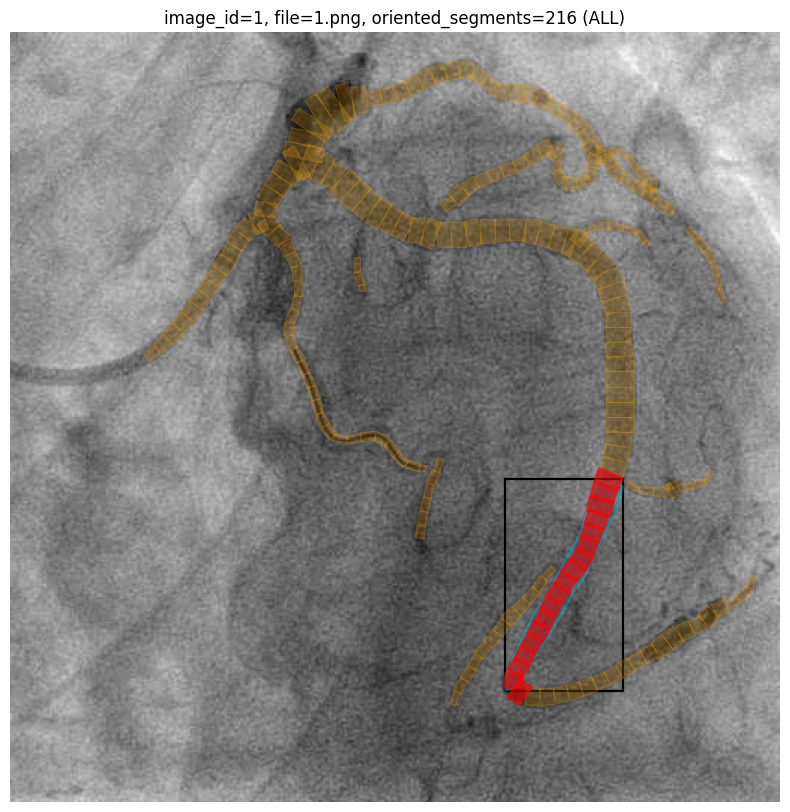

In [ ]:
from matplotlib.patches import Polygon, Rectangle


def parse_json_points(value):
    if isinstance(value, str):
        return np.asarray(json.loads(value), dtype=float)
    if isinstance(value, list):
        return np.asarray(value, dtype=float)
    return np.empty((0, 2), dtype=float)


def draw_coco_segmentation(ax, segmentation, color="cyan", alpha=0.28, linewidth=1.5):
    if segmentation is None:
        return
    if isinstance(segmentation, str):
        try:
            segmentation = json.loads(segmentation)
        except Exception:
            return
    if not isinstance(segmentation, list):
        return

    for poly in segmentation:
        arr = np.asarray(poly, dtype=float).reshape(-1, 2)
        if len(arr) < 3:
            continue
        ax.add_patch(
            Polygon(
                arr,
                closed=True,
                fill=True,
                edgecolor=color,
                facecolor=color,
                linewidth=linewidth,
                alpha=alpha,
            )
        )


def show_oriented_segments(
    image_id: int | None = None,
    file_name: str | None = None,
    max_segments: int | None = None,
    show_only_positive_neighborhood: bool = False,
    draw_bbox: bool = True,
    draw_segmentation: bool = True,
    figsize=(10, 10),
):
    """
    Pokazuje oriented segmenty dla danego obrazu.

    Domyślnie pokazuje WSZYSTKIE segmenty zapisane w df dla image_id.
    Uwaga: jeśli show_only_positive_neighborhood=True, wtedy celowo pokazuje tylko okolice label=1.
    """
    if "df" not in globals() or len(df) == 0:
        raise RuntimeError("Brak df. Uruchom generowanie danych.")

    if image_id is None and file_name is None:
        positives = df[df["label"] == 1]
        if len(positives):
            image_id = int(positives.iloc[0]["image_id"])
        else:
            image_id = int(df.iloc[0]["image_id"])

    if file_name is not None:
        image_id = image_id_by_file[file_name]

    image_id = int(image_id)
    img_info = image_by_id[image_id]
    file_name = img_info["file_name"]
    image_path = IMAGE_DIR / file_name

    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(image_path)

    sub_all = df[df["image_id"].astype(int) == image_id].copy()
    sub = sub_all.copy()

    if show_only_positive_neighborhood and len(sub) and (sub["label"] == 1).any():
        pos = sub[sub["label"] == 1]
        xmin = pos["axis_bbox_x_min"].min() - 60
        xmax = pos["axis_bbox_x_max"].max() + 60
        ymin = pos["axis_bbox_y_min"].min() - 60
        ymax = pos["axis_bbox_y_max"].max() + 60
        sub = sub[(sub["center_x"].between(xmin, xmax)) & (sub["center_y"].between(ymin, ymax))]

    if max_segments is not None and len(sub) > max_segments:
        # Zachowaj wszystkie pozytywy, resztę dobierz losowo.
        pos = sub[sub["label"] == 1]
        neg = sub[sub["label"] == 0]
        n_neg = max(0, max_segments - len(pos))
        neg = neg.sample(min(n_neg, len(neg)), random_state=0)
        sub = pd.concat([pos, neg]).sort_index()

    print(f"image_id={image_id}, file={file_name}")
    print(f"Wszystkie segmenty w df dla tego obrazu: {len(sub_all)}")
    print(f"Segmenty aktualnie rysowane: {len(sub)}")
    if len(sub_all):
        print("label counts all:")
        print(sub_all["label"].value_counts(dropna=False).sort_index())

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img, cmap="gray")
    suffix = "ALL" if not show_only_positive_neighborhood else "positive neighborhood"
    ax.set_title(f"image_id={image_id}, file={file_name}, oriented_segments={len(sub)} ({suffix})")
    ax.axis("off")

    # maska segmentation stenosis jako półprzezroczysty obszar
    if draw_segmentation:
        sten_mask = stenosis_mask_by_image.get(image_id)
        if sten_mask is not None and sten_mask.sum() > 0:
            masked = np.ma.masked_where(sten_mask == 0, sten_mask)
            ax.imshow(masked, alpha=0.22)

    # bboxy i polygon segmentation oryginalnych anotacji
    for ann in anns_by_image.get(image_id, []):
        if draw_bbox:
            x, y, w, h = ann["bbox_xywh"]
            ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=1.6, edgecolor="black"))
        if draw_segmentation:
            draw_coco_segmentation(ax, ann.get("segmentation"), color="cyan", alpha=0.20)

    # obrócone prostokąty fragmentów: najpierw 0, potem 1 na wierzchu
    if len(sub):
        for _, r in sub.sort_values("label").iterrows():
            verts = parse_json_points(r["oriented_box_vertices_xy"])
            if len(verts) != 4:
                continue
            if int(r["label"]) == 1:
                edgecolor = "red"
                linewidth = 1.8
                alpha = 0.55
            else:
                edgecolor = "orange"
                linewidth = 0.8
                alpha = 0.20
            ax.add_patch(
                Polygon(
                    verts,
                    closed=True,
                    fill=True,
                    edgecolor=edgecolor,
                    facecolor=edgecolor,
                    alpha=alpha,
                    linewidth=linewidth,
                )
            )

    plt.show()

show_oriented_segments(image_id=1, max_segments=None, show_only_positive_neighborhood=False)


## 12b. Diagnostyka pełnego pipeline'u dla jednego obrazu

Ta komórka pokazuje, czy problem jest w segmencie rysowania, w masce, w skeletonie, czy w grafie.

Panele:

1. oryginalny obraz + bbox/polygon stenosis,
2. maska segmentacji zapisana przez pipeline,
3. skeleton finalny po junction cleanup,
4. wszystkie oriented segmenty zapisane w `df` dla danego obrazu.


image_id=1, file=1.png
annotations: 1
oriented segments in df: 216
mask: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/debug_pipeline/1_mask.png exists= True
skeleton raw: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/debug_pipeline/1_skeleton_raw.png exists= True
skeleton pruned: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/debug_pipeline/1_skeleton_pruned.png exists= True
skeleton final: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/debug_pipeline/1_skeleton_final.png exists= True
label counts:
label
0    198
1     18
Name: count, dtype: int64
branch counts:
branch_id
0     26
1     16
2      1
3      4
4      4
5      5
6     21
7      1
8      1
9      3
10    13
11    25
12     6
13     7
14    54
15     3
16     6
17     3
18     1
19     4
20    12
Name: count, dtype: int64


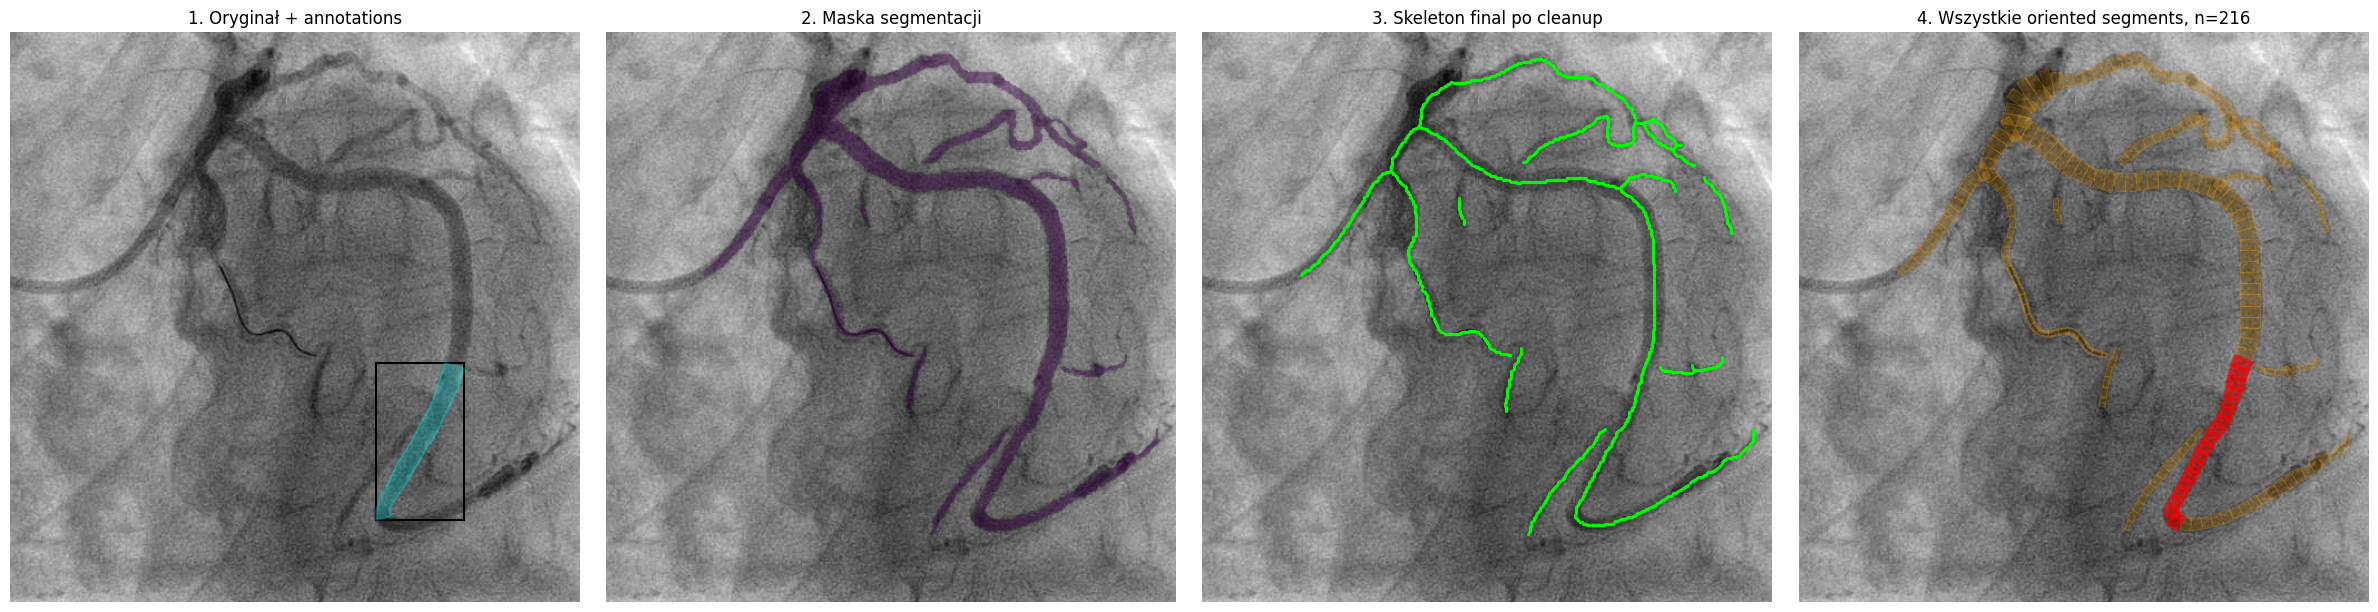

In [40]:
def read_debug_gray(image_id: int, name: str):
    p = DEBUG_DIR / f"{image_id}_{name}.png"
    if not p.exists():
        return None, p
    arr = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    return arr, p


def show_pipeline_debug(image_id: int = 1):
    image_id = int(image_id)
    img_info = image_by_id[image_id]
    file_name = img_info["file_name"]
    image_path = IMAGE_DIR / file_name
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(image_path)

    mask, mask_path = read_debug_gray(image_id, "mask")
    skel_raw, skel_raw_path = read_debug_gray(image_id, "skeleton_raw")
    skel_pruned, skel_pruned_path = read_debug_gray(image_id, "skeleton_pruned")
    skel_final, skel_final_path = read_debug_gray(image_id, "skeleton_final")

    sub = df[df["image_id"].astype(int) == image_id].copy()
    anns = anns_by_image.get(image_id, [])

    print(f"image_id={image_id}, file={file_name}")
    print(f"annotations: {len(anns)}")
    print(f"oriented segments in df: {len(sub)}")
    print("mask:", mask_path, "exists=", mask is not None)
    print("skeleton raw:", skel_raw_path, "exists=", skel_raw is not None)
    print("skeleton pruned:", skel_pruned_path, "exists=", skel_pruned is not None)
    print("skeleton final:", skel_final_path, "exists=", skel_final is not None)
    if len(sub):
        print("label counts:")
        print(sub["label"].value_counts(dropna=False).sort_index())
        print("branch counts:")
        print(sub["branch_id"].value_counts().sort_index())

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    # 1. Original + annotations
    ax = axes[0]
    ax.imshow(img, cmap="gray")
    ax.set_title("1. Oryginał + annotations")
    ax.axis("off")
    for ann in anns:
        x, y, w, h = ann["bbox_xywh"]
        ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=1.5, edgecolor="black"))
        draw_coco_segmentation(ax, ann.get("segmentation"), color="cyan", alpha=0.25)

    # 2. Mask
    ax = axes[1]
    ax.imshow(img, cmap="gray")
    ax.set_title("2. Maska segmentacji")
    ax.axis("off")
    if mask is not None:
        ax.imshow(np.ma.masked_where(mask == 0, mask), alpha=0.35)
    else:
        ax.text(10, 25, "Brak maski debug.\nUruchom generowanie df ponownie.", color="yellow", bbox=dict(facecolor="black", alpha=0.7))

    # 3. Skeleton final
    ax = axes[2]
    ax.imshow(img, cmap="gray")
    ax.set_title("3. Skeleton final po cleanup")
    ax.axis("off")
    if skel_final is not None:
        ys, xs = np.where(skel_final > 0)
        ax.scatter(xs, ys, s=2, c="lime", alpha=0.8)
    else:
        ax.text(10, 25, "Brak skeleton_final debug.\nUruchom generowanie df ponownie.", color="yellow", bbox=dict(facecolor="black", alpha=0.7))

    # 4. All oriented segments
    ax = axes[3]
    ax.imshow(img, cmap="gray")
    ax.set_title(f"4. Wszystkie oriented segments, n={len(sub)}")
    ax.axis("off")
    for _, r in sub.sort_values("label").iterrows():
        verts = parse_json_points(r["oriented_box_vertices_xy"])
        if len(verts) != 4:
            continue
        if int(r["label"]) == 1:
            color = "red"
            alpha = 0.55
            lw = 1.8
        else:
            color = "orange"
            alpha = 0.20
            lw = 0.7
        ax.add_patch(Polygon(verts, closed=True, fill=True, edgecolor=color, facecolor=color, alpha=alpha, linewidth=lw))

    plt.tight_layout()
    plt.show()


show_pipeline_debug(image_id=1)


## 13. Podgląd samych anotacji `segmentation` z `train.json`

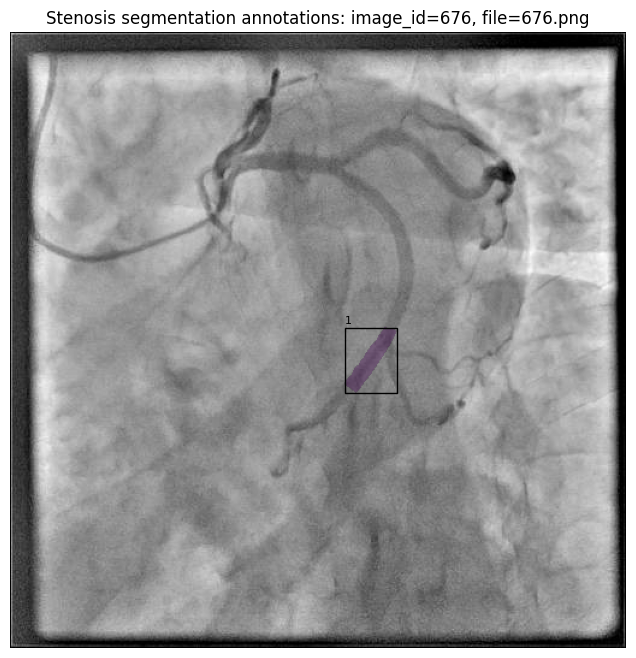

In [41]:
def show_stenosis_annotations(image_id: int | None = None, file_name: str | None = None):
    if image_id is None and file_name is None:
        image_id = next(iter(anns_by_image.keys()))
    if file_name is not None:
        image_id = image_id_by_file[file_name]

    img_info = image_by_id[int(image_id)]
    file_name = img_info["file_name"]
    image_path = IMAGE_DIR / file_name
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Stenosis segmentation annotations: image_id={image_id}, file={file_name}")
    ax.axis("off")

    for annm in ann_masks_by_image.get(int(image_id), []):
        mask = annm["mask"]
        masked = np.ma.masked_where(mask == 0, mask)
        ax.imshow(masked, alpha=0.35)

        x, y, w, h = annm["bbox_xywh"]
        rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=1.0)
        ax.add_patch(rect)
        ax.text(x, max(0, y - 3), str(annm["ann_id"]), fontsize=8)

    plt.show()


show_stenosis_annotations(image_id=next(iter(anns_by_image.keys())))


## 14. Minimalny sanity-check klasyfikatora

To tylko szybki test, czy CSV nadaje się do uczenia. Do właściwych eksperymentów dobierz model, sampling i walidację grupowaną po `image_id`.

In [42]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

feature_cols = [
    "center_x",
    "center_y",
    "segment_length_px",
    "patch_width_px",
    "patch_area_px",
    "angle_deg",
    "mean_diameter",
    "min_diameter",
    "max_diameter",
    "std_diameter",
    "diameter_drop",
    "branch_distance",
    "branch_euclidean_distance",
    "branch_tortuosity",
    "branch_type",
]

if "train_ready_df" not in globals():
    train_ready_df = df[[*feature_cols, "image_id", "label"]].copy()

clf_df = train_ready_df.dropna(subset=feature_cols + ["label", "image_id"]).copy()
print("clf_df:", clf_df.shape)
print(clf_df["label"].value_counts().sort_index())

if len(clf_df["label"].unique()) < 2:
    print("Za mało klas do treningu. Zwiększ FAST_DEV_LIMIT albo wygeneruj pełniejszy zbiór.")
else:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, test_idx = next(splitter.split(clf_df, clf_df["label"], groups=clf_df["image_id"]))

    X_train = clf_df.iloc[train_idx][feature_cols]
    y_train = clf_df.iloc[train_idx]["label"].astype(int)
    X_test = clf_df.iloc[test_idx][feature_cols]
    y_test = clf_df.iloc[test_idx]["label"].astype(int)

    clf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    )
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, digits=4))

    importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
    display(importances.to_frame("importance"))


clf_df: (194729, 22)
label
0    173577
1     21152
Name: count, dtype: int64
[[41704   393]
 [ 4872   403]]
              precision    recall  f1-score   support

           0     0.8954    0.9907    0.9406     42097
           1     0.5063    0.0764    0.1328      5275

    accuracy                         0.8889     47372
   macro avg     0.7008    0.5335    0.5367     47372
weighted avg     0.8521    0.8889    0.8507     47372



,importance
center_x,0.136454
max_diameter,0.093814
mean_diameter,0.085802
patch_width_px,0.082709
center_y,0.081444
branch_tortuosity,0.071826
patch_area_px,0.069336
branch_euclidean_distance,0.065262
branch_distance,0.063761
angle_deg,0.055344


## 15. XGBoost na obróconych segmentach + cechy sąsiednich segmentów

Ten baseline klasyfikuje każdy obrócony fragment naczynia jako `0/1`. Split jest robiony po `image_id`, żeby fragmenty z tego samego obrazu nie trafiły jednocześnie do train i test.  

Ważne: do modelu **nie** trafiają kolumny pochodzące bezpośrednio z anotacji (`matched_annotation_*`, `positive_patch_overlap_fraction`, `positive_patch_intersection_area_px`) ani geometria debugowa jako JSON.

In [43]:
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

import matplotlib.pyplot as plt

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError(
        "Brak pakietu xgboost. Zainstaluj w terminalu: pip install xgboost"
    ) from e

assert "df" in globals(), "Brak df — najpierw uruchom generowanie oriented segments."

xgb_df = df.copy()
xgb_df = xgb_df[xgb_df["label"].isin([0, 1])].copy()
xgb_df["label"] = xgb_df["label"].astype(int)

print("xgb_df shape:", xgb_df.shape)
print("Label distribution:")
print(xgb_df["label"].value_counts().sort_index())
print("\nLabel proportions:")
print(xgb_df["label"].value_counts(normalize=True).sort_index())

if xgb_df["label"].nunique() < 2:
    raise ValueError("W danych jest tylko jedna klasa. Zwiększ FAST_DEV_LIMIT albo wygeneruj więcej obrazów.")


xgb_df shape: (194922, 40)
Label distribution:
label
0    173765
1     21157
Name: count, dtype: int64

Label proportions:
label
0    0.891459
1    0.108541
Name: proportion, dtype: float64


### 15.1. Dodanie kontekstu sąsiednich segmentów

Stenoza jest lokalnym spadkiem średnicy, więc sam pojedynczy fragment 10 px może być za mało informatywny. Poniżej dodajemy cechy poprzedniego i następnego fragmentu na tej samej gałęzi oraz różnice względem sąsiadów.

In [ ]:
sort_cols = ["image_id", "branch_id", "local_segment_id"]
for col in sort_cols:
    assert col in xgb_df.columns, f"Brakuje kolumny: {col}"

xgb_df = xgb_df.sort_values(sort_cols).reset_index(drop=True)
group_cols = ["image_id", "branch_id"]

neighbor_base_cols = [
    "segment_length_px",
    "patch_width_px",
    "patch_area_px",
    "angle_deg",
    "mean_diameter",
    "min_diameter",
    "max_diameter",
    "std_diameter",
    "diameter_drop",
]
neighbor_base_cols = [c for c in neighbor_base_cols if c in xgb_df.columns]

for col in neighbor_base_cols:
    xgb_df[f"prev_{col}"] = xgb_df.groupby(group_cols)[col].shift(1)
    xgb_df[f"next_{col}"] = xgb_df.groupby(group_cols)[col].shift(-1)
    xgb_df[f"neighbor_mean_{col}"] = xgb_df[[f"prev_{col}", f"next_{col}"]].mean(axis=1)
    xgb_df[f"diff_vs_prev_{col}"] = xgb_df[col] - xgb_df[f"prev_{col}"]
    xgb_df[f"diff_vs_next_{col}"] = xgb_df[col] - xgb_df[f"next_{col}"]
    xgb_df[f"diff_vs_neighbor_mean_{col}"] = xgb_df[col] - xgb_df[f"neighbor_mean_{col}"]

eps = 1e-6
if {"mean_diameter", "neighbor_mean_mean_diameter"}.issubset(xgb_df.columns):
    xgb_df["mean_diameter_ratio_to_neighbors"] = xgb_df["mean_diameter"] / (xgb_df["neighbor_mean_mean_diameter"] + eps)

if {"min_diameter", "neighbor_mean_mean_diameter"}.issubset(xgb_df.columns):
    xgb_df["min_diameter_ratio_to_neighbor_mean"] = xgb_df["min_diameter"] / (xgb_df["neighbor_mean_mean_diameter"] + eps)

if {"min_diameter", "prev_mean_diameter", "next_mean_diameter"}.issubset(xgb_df.columns):
    neighbor_mean = xgb_df[["prev_mean_diameter", "next_mean_diameter"]].mean(axis=1)
    xgb_df["local_stenosis_score"] = 1.0 - (xgb_df["min_diameter"] / (neighbor_mean + eps))

numeric_cols = xgb_df.select_dtypes(include=[np.number]).columns.tolist()
xgb_df[numeric_cols] = xgb_df[numeric_cols].replace([np.inf, -np.inf], np.nan)

for col in xgb_df.columns:
    if col.startswith("diff_vs_"):
        xgb_df[col] = xgb_df[col].fillna(0)

numeric_cols = xgb_df.select_dtypes(include=[np.number]).columns.tolist()
xgb_df[numeric_cols] = xgb_df[numeric_cols].fillna(xgb_df[numeric_cols].median(numeric_only=True))

added_neighbor_cols = [
    c for c in xgb_df.columns
    if c.startswith(("prev_", "next_", "neighbor_mean_", "diff_vs_"))
    or c in ["mean_diameter_ratio_to_neighbors", "min_diameter_ratio_to_neighbor_mean", "local_stenosis_score"]
]

print("Dodane cechy sąsiedztwa:", len(added_neighbor_cols))
print(added_neighbor_cols[:40])


Dodane cechy sąsiedztwa: 57
['prev_segment_length_px', 'next_segment_length_px', 'neighbor_mean_segment_length_px', 'diff_vs_prev_segment_length_px', 'diff_vs_next_segment_length_px', 'diff_vs_neighbor_mean_segment_length_px', 'prev_patch_width_px', 'next_patch_width_px', 'neighbor_mean_patch_width_px', 'diff_vs_prev_patch_width_px', 'diff_vs_next_patch_width_px', 'diff_vs_neighbor_mean_patch_width_px', 'prev_patch_area_px', 'next_patch_area_px', 'neighbor_mean_patch_area_px', 'diff_vs_prev_patch_area_px', 'diff_vs_next_patch_area_px', 'diff_vs_neighbor_mean_patch_area_px', 'prev_angle_deg', 'next_angle_deg', 'neighbor_mean_angle_deg', 'diff_vs_prev_angle_deg', 'diff_vs_next_angle_deg', 'diff_vs_neighbor_mean_angle_deg', 'prev_mean_diameter', 'next_mean_diameter', 'neighbor_mean_mean_diameter', 'diff_vs_prev_mean_diameter', 'diff_vs_next_mean_diameter', 'diff_vs_neighbor_mean_mean_diameter', 'prev_min_diameter', 'next_min_diameter', 'neighbor_mean_min_diameter', 'diff_vs_prev_min_diame

### 15.2. Wybór cech i split po `image_id`

In [ ]:
exclude_cols = {
    "label",
    "image_id",
    "file_name",
    "branch_id",
    "oriented_segment_id",
    "local_segment_id",
    "matched_annotation_ids",
    "matched_annotation_bboxes_xywh",
    "positive_patch_overlap_fraction",
    "positive_patch_intersection_area_px",
    "oriented_box_vertices_xy",
    "centerline_points_xy",
    "patch_pixels_xy",
    "used_junction_cleanup",
}

feature_cols = [
    c for c in xgb_df.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(xgb_df[c])
]

print("Liczba feature_cols:", len(feature_cols))
print(feature_cols)

X_all = xgb_df[feature_cols].copy()
y_all = xgb_df["label"].astype(int).copy()
groups = xgb_df["image_id"].copy()

def grouped_train_val_test_split(data, labels, group_ids, random_state=42, test_size=0.15, val_size=0.15, max_tries=100):

    for seed in range(random_state, random_state + max_tries):
        gss1 = GroupShuffleSplit(n_splits=1, test_size=(test_size + val_size), random_state=seed)
        train_idx, temp_idx = next(gss1.split(data, labels, groups=group_ids))

        temp_group_ids = group_ids.iloc[temp_idx]
        temp_labels = labels.iloc[temp_idx]
        relative_test_size = test_size / (test_size + val_size)

        gss2 = GroupShuffleSplit(n_splits=1, test_size=relative_test_size, random_state=seed + 1000)
        val_rel_idx, test_rel_idx = next(gss2.split(data.iloc[temp_idx], temp_labels, groups=temp_group_ids))

        val_idx = temp_idx[val_rel_idx]
        test_idx = temp_idx[test_rel_idx]

        splits = {
            "train": labels.iloc[train_idx],
            "val": labels.iloc[val_idx],
            "test": labels.iloc[test_idx],
        }
        if all(s.nunique() == 2 for s in splits.values()):
            return train_idx, val_idx, test_idx, seed

    print("Uwaga: nie udało się znaleźć splitu, gdzie każda część ma obie klasy. Używam ostatniego splitu.")
    return train_idx, val_idx, test_idx, seed

train_idx, val_idx, test_idx, split_seed = grouped_train_val_test_split(X_all, y_all, groups)

X_train, y_train = X_all.iloc[train_idx], y_all.iloc[train_idx]
X_val, y_val = X_all.iloc[val_idx], y_all.iloc[val_idx]
X_test, y_test = X_all.iloc[test_idx], y_all.iloc[test_idx]

print("split_seed:", split_seed)
print("Train:", X_train.shape, y_train.value_counts().sort_index().to_dict(), "images:", groups.iloc[train_idx].nunique())
print("Val:  ", X_val.shape, y_val.value_counts().sort_index().to_dict(), "images:", groups.iloc[val_idx].nunique())
print("Test: ", X_test.shape, y_test.value_counts().sort_index().to_dict(), "images:", groups.iloc[test_idx].nunique())


Liczba feature_cols: 83
['arc_start_px', 'arc_end_px', 'center_x', 'center_y', 'segment_length_px', 'patch_width_px', 'patch_area_px', 'angle_deg', 'axis_bbox_x_min', 'axis_bbox_y_min', 'axis_bbox_x_max', 'axis_bbox_y_max', 'axis_bbox_width', 'axis_bbox_height', 'mean_diameter', 'min_diameter', 'max_diameter', 'std_diameter', 'diameter_drop', 'branch_distance', 'branch_euclidean_distance', 'branch_tortuosity', 'branch_type', 'n_junction_certain', 'n_junction_false', 'n_junction_not', 'prev_segment_length_px', 'next_segment_length_px', 'neighbor_mean_segment_length_px', 'diff_vs_prev_segment_length_px', 'diff_vs_next_segment_length_px', 'diff_vs_neighbor_mean_segment_length_px', 'prev_patch_width_px', 'next_patch_width_px', 'neighbor_mean_patch_width_px', 'diff_vs_prev_patch_width_px', 'diff_vs_next_patch_width_px', 'diff_vs_neighbor_mean_patch_width_px', 'prev_patch_area_px', 'next_patch_area_px', 'neighbor_mean_patch_area_px', 'diff_vs_prev_patch_area_px', 'diff_vs_next_patch_area_px'

### 15.3. Trening XGBoost

Model jest ustawiony konserwatywnie: płytkie drzewa, regularizacja i `scale_pos_weight`, bo pozytywnych stenoz zwykle jest dużo mniej niż negatywnych fragmentów.

In [46]:
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / max(n_pos, 1)
print("scale_pos_weight:", scale_pos_weight)

xgb_model = XGBClassifier(
    n_estimators=800,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    reg_lambda=2.0,
    reg_alpha=0.1,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50,
)

print("Model trained.")


scale_pos_weight: 8.118310423061525
[0]	validation_0-aucpr:0.26519	validation_1-aucpr:0.24512
[50]	validation_0-aucpr:0.35145	validation_1-aucpr:0.32131
[100]	validation_0-aucpr:0.38075	validation_1-aucpr:0.34175
[150]	validation_0-aucpr:0.40516	validation_1-aucpr:0.35788
[200]	validation_0-aucpr:0.42303	validation_1-aucpr:0.36608
[250]	validation_0-aucpr:0.43466	validation_1-aucpr:0.37269
[300]	validation_0-aucpr:0.44447	validation_1-aucpr:0.37694
[350]	validation_0-aucpr:0.45235	validation_1-aucpr:0.38199
[400]	validation_0-aucpr:0.45936	validation_1-aucpr:0.38569
[450]	validation_0-aucpr:0.46580	validation_1-aucpr:0.38713
[500]	validation_0-aucpr:0.47117	validation_1-aucpr:0.38739
[550]	validation_0-aucpr:0.47557	validation_1-aucpr:0.38840
[600]	validation_0-aucpr:0.48012	validation_1-aucpr:0.38949
[650]	validation_0-aucpr:0.48342	validation_1-aucpr:0.38953
[700]	validation_0-aucpr:0.48768	validation_1-aucpr:0.39017
[750]	validation_0-aucpr:0.49104	validation_1-aucpr:0.39063
[799]	v

### 15.4. Wyniki: ROC-AUC, AUPRC, confusion matrix, dobór progu

In [ ]:
proba_val = xgb_model.predict_proba(X_val)[:, 1]
proba_test = xgb_model.predict_proba(X_test)[:, 1]

roc_auc_val = roc_auc_score(y_val, proba_val) if y_val.nunique() == 2 else np.nan
ap_val = average_precision_score(y_val, proba_val) if y_val.nunique() == 2 else np.nan
roc_auc_test = roc_auc_score(y_test, proba_test) if y_test.nunique() == 2 else np.nan
ap_test = average_precision_score(y_test, proba_test) if y_test.nunique() == 2 else np.nan

print(f"VAL  ROC-AUC={roc_auc_val:.4f}, AUPRC/AP={ap_val:.4f}")
print(f"TEST ROC-AUC={roc_auc_test:.4f}, AUPRC/AP={ap_test:.4f}")

target_recall = 0.85
precision_val, recall_val, thresholds_val = precision_recall_curve(y_val, proba_val)
valid = np.where(recall_val[:-1] >= target_recall)[0]

if len(valid):
    f1_val = 2 * precision_val[:-1] * recall_val[:-1] / (precision_val[:-1] + recall_val[:-1] + 1e-12)
    best_idx = valid[np.argmax(f1_val[valid])]
    selected_threshold = float(thresholds_val[best_idx])
else:
    selected_threshold = 0.5

print(f"Selected threshold from VAL for recall>={target_recall}: {selected_threshold:.4f}")

pred_test_05 = (proba_test >= 0.5).astype(int)
pred_test_sel = (proba_test >= selected_threshold).astype(int)

print("\nTEST @ threshold=0.5")
print(confusion_matrix(y_test, pred_test_05))
print(classification_report(y_test, pred_test_05, digits=4))

print(f"\nTEST @ selected_threshold={selected_threshold:.4f}")
print(confusion_matrix(y_test, pred_test_sel))
print(classification_report(y_test, pred_test_sel, digits=4))


VAL  ROC-AUC=0.8526, AUPRC/AP=0.3919
TEST ROC-AUC=0.8442, AUPRC/AP=0.3595
Selected threshold from VAL for recall>=0.85: 0.4566

TEST @ threshold=0.5
[[19198  6854]
 [  584  2526]]
              precision    recall  f1-score   support

           0     0.9705    0.7369    0.8377     26052
           1     0.2693    0.8122    0.4045      3110

    accuracy                         0.7449     29162
   macro avg     0.6199    0.7746    0.6211     29162
weighted avg     0.8957    0.7449    0.7915     29162


TEST @ selected_threshold=0.4566
[[18485  7567]
 [  511  2599]]
              precision    recall  f1-score   support

           0     0.9731    0.7095    0.8207     26052
           1     0.2557    0.8357    0.3915      3110

    accuracy                         0.7230     29162
   macro avg     0.6144    0.7726    0.6061     29162
weighted avg     0.8966    0.7230    0.7749     29162



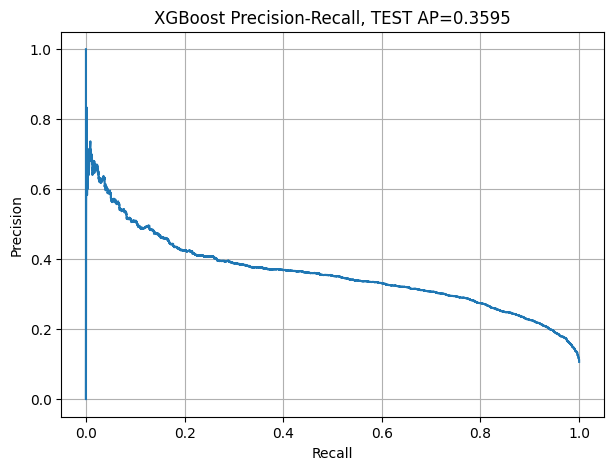

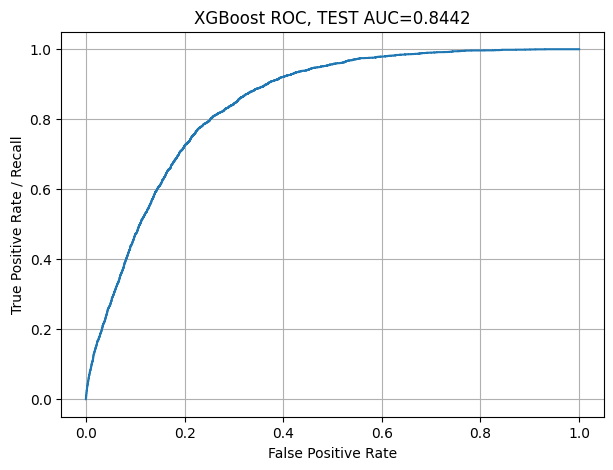

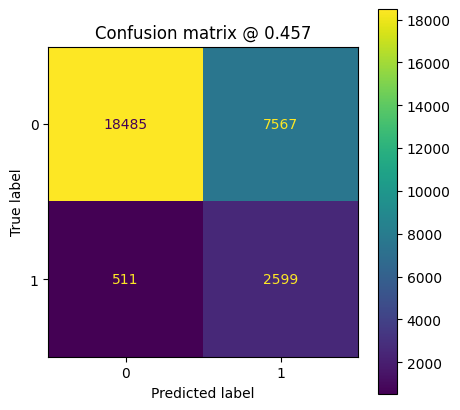

In [ ]:
precision_test, recall_test, thresholds_test = precision_recall_curve(y_test, proba_test)

plt.figure(figsize=(7, 5))
plt.plot(recall_test, precision_test)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"XGBoost Precision-Recall, TEST AP={ap_test:.4f}")
plt.grid(True)
plt.show()

fpr_test, tpr_test, _ = roc_curve(y_test, proba_test)
plt.figure(figsize=(7, 5))
plt.plot(fpr_test, tpr_test)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title(f"XGBoost ROC, TEST AUC={roc_auc_test:.4f}")
plt.grid(True)
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_test_sel, ax=ax, values_format="d")
ax.set_title(f"Confusion matrix @ {selected_threshold:.3f}")
plt.show()


### 15.5. Feature importance i zapis predykcji

,feature,importance
16,max_diameter,0.174265
5,patch_width_px,0.106356
34,neighbor_mean_patch_width_px,0.063061
52,neighbor_mean_mean_diameter,0.044803
8,axis_bbox_x_min,0.035867
14,mean_diameter,0.032118
22,branch_type,0.031823
2,center_x,0.027837
64,neighbor_mean_max_diameter,0.025994
40,neighbor_mean_patch_area_px,0.022018


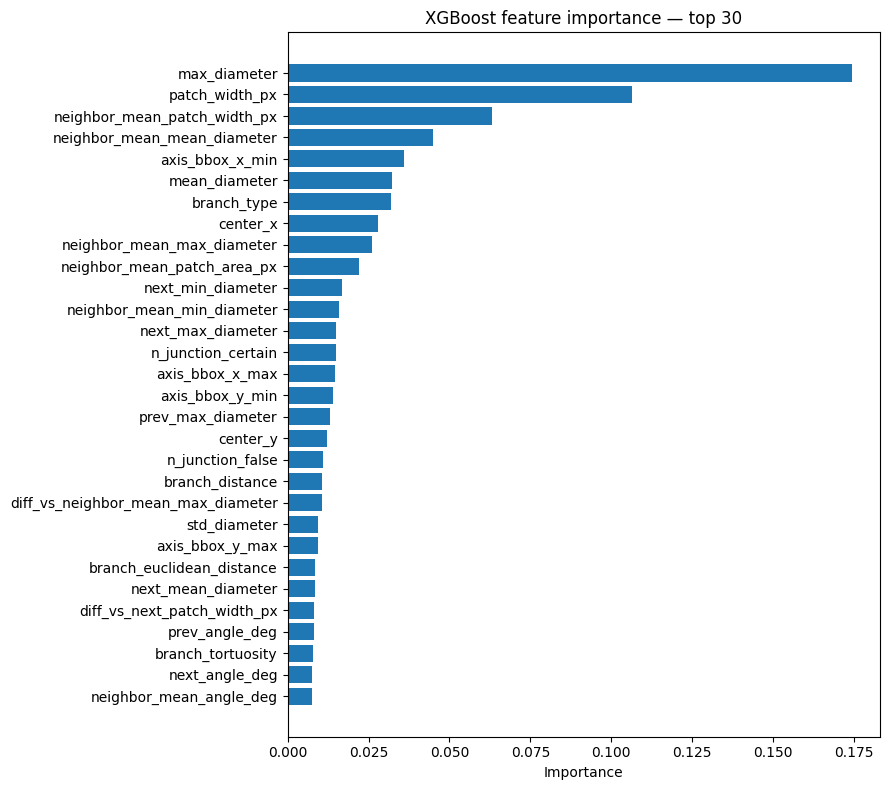

Zapisano predykcje: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/xgboost_oriented_segments_predictions.csv
Zapisano importance: /home/piotrrusak/Agh/coronary-stenosis-detection/notebooks/processed/stenosis_oriented_segments/xgboost_feature_importance.csv


In [ ]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance_df.head(40))

plt.figure(figsize=(9, 8))
top_imp = importance_df.head(30).iloc[::-1]
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importance")
plt.title("XGBoost feature importance — top 30")
plt.tight_layout()
plt.show()

xgb_predictions_df = xgb_df.copy()
xgb_predictions_df["split"] = "unused"
xgb_predictions_df.loc[xgb_predictions_df.index[train_idx], "split"] = "train"
xgb_predictions_df.loc[xgb_predictions_df.index[val_idx], "split"] = "val"
xgb_predictions_df.loc[xgb_predictions_df.index[test_idx], "split"] = "test"

xgb_predictions_df["xgb_pred_proba"] = np.nan
xgb_predictions_df.loc[xgb_predictions_df.index[val_idx], "xgb_pred_proba"] = proba_val
xgb_predictions_df.loc[xgb_predictions_df.index[test_idx], "xgb_pred_proba"] = proba_test
xgb_predictions_df["xgb_pred_label"] = np.nan
xgb_predictions_df.loc[xgb_predictions_df.index[test_idx], "xgb_pred_label"] = pred_test_sel

pred_csv = OUTPUT_DIR / "xgboost_oriented_segments_predictions.csv"
importance_csv = OUTPUT_DIR / "xgboost_feature_importance.csv"
xgb_predictions_df.to_csv(pred_csv, index=False)
importance_df.to_csv(importance_csv, index=False)

print("Zapisano predykcje:", pred_csv)
print("Zapisano importance:", importance_csv)


### 15.6. Wizualizacja predykcji XGBoosta na obrazie

Kolory: czerwony = true positive, pomarańczowy = true negative, fioletowy = false positive, niebieski = false negative. Pokazujemy tylko obrazy ze splitu testowego.

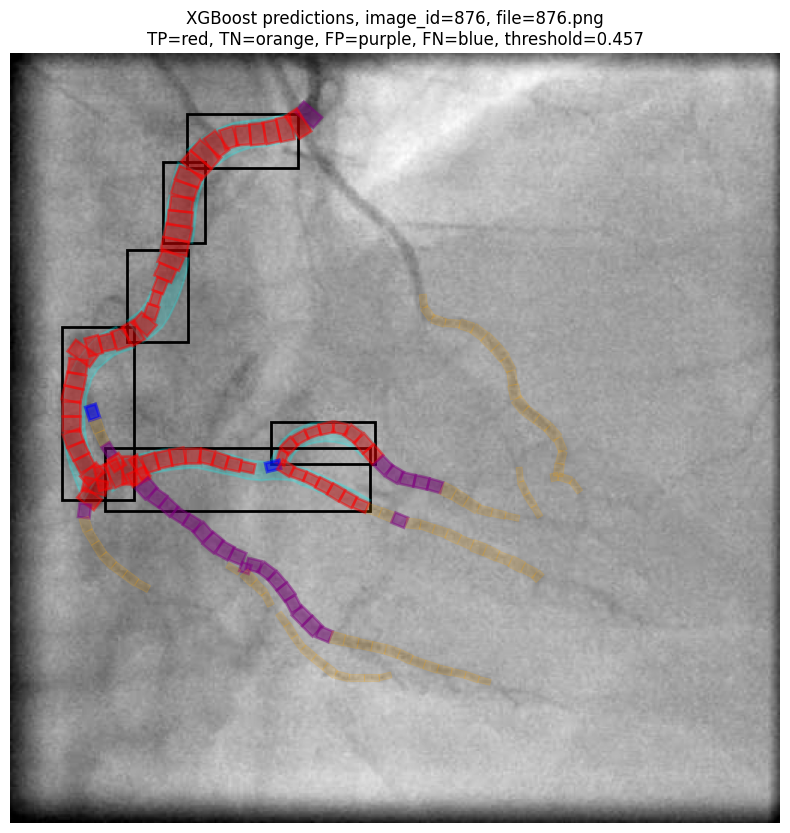

Counts true/pred:


pred,0,1
true,,
0,79,27
1,2,67


In [ ]:
from matplotlib.patches import Polygon, Rectangle


def plot_xgb_predictions_for_image(image_id: int | None = None, threshold: float | None = None, only_test: bool = True):
    if threshold is None:
        threshold = selected_threshold

    plot_df = xgb_predictions_df.copy()
    if only_test:
        plot_df = plot_df[plot_df["split"] == "test"].copy()

    if image_id is None:
        candidates = plot_df.groupby("image_id")["label"].sum().sort_values(ascending=False)
        if len(candidates) == 0:
            raise ValueError("Brak danych do wizualizacji.")
        image_id = int(candidates.index[0])

    rec = image_by_id[int(image_id)]
    img_path = IMAGE_DIR / rec["file_name"]
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(img_path)

    sub = plot_df[plot_df["image_id"].astype(int) == int(image_id)].copy()
    if len(sub) == 0:
        raise ValueError(f"Brak segmentów dla image_id={image_id} w wybranym splicie.")

    sub["pred"] = (sub["xgb_pred_proba"] >= threshold).astype(int)

    anns = anns_by_image.get(int(image_id), [])

    _, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(img, cmap="gray")
    ax.set_title(
        f"XGBoost predictions, image_id={image_id}, file={rec['file_name']}\n"
        f"TP=red, TN=orange, FP=purple, FN=blue, threshold={threshold:.3f}"
    )
    ax.axis("off")

    for ann in anns:
        if "bbox" in ann and ann["bbox"] is not None:
            x, y, bw, bh = ann["bbox"]
            ax.add_patch(Rectangle((x, y), bw, bh, linewidth=2, edgecolor="black", facecolor="none"))
        seg = ann.get("segmentation")
        if isinstance(seg, list):
            for poly in seg:
                arr = np.asarray(poly, dtype=float).reshape(-1, 2)
                if len(arr) >= 3:
                    ax.add_patch(Polygon(arr, closed=True, edgecolor="cyan", facecolor="cyan", alpha=0.2, linewidth=1.5))

    for _, r in sub.iterrows():
        box = parse_json_points(r["oriented_box_vertices_xy"])
        if box is None or len(box) < 4:
            continue

        true = int(r["label"])
        pred = int(r["pred"])

        if true == 1 and pred == 1:
            color = "red"       # TP
            alpha = 0.45
            lw = 1.8
        elif true == 0 and pred == 0:
            color = "orange"    # TN
            alpha = 0.16
            lw = 0.7
        elif true == 0 and pred == 1:
            color = "purple"    # FP
            alpha = 0.45
            lw = 1.8
        else:
            color = "blue"      # FN
            alpha = 0.55
            lw = 2.2

        ax.add_patch(Polygon(box, closed=True, edgecolor=color, facecolor=color, alpha=alpha, linewidth=lw))

    plt.show()

    print("Counts true/pred:")
    display(pd.crosstab(sub["label"], sub["pred"], rownames=["true"], colnames=["pred"]))
    return sub

# Automatycznie pokaż jeden obraz testowy z największą liczbą pozytywów.
_ = plot_xgb_predictions_for_image()
